# CKA Analysis

In [1]:
import math
import numpy as np


def centering(K):
    n = K.shape[0]
    unit = np.ones([n, n])
    I = np.eye(n)
    H = I - unit / n

    return np.dot(np.dot(H, K), H)  # HKH are the same with KH, KH is the first centering, H(KH) do the second time, results are the sme with one time centering
    # return np.dot(H, K)  # KH


def rbf(X, sigma=None):
    GX = np.dot(X, X.T)
    KX = np.diag(GX) - GX + (np.diag(GX) - GX).T
    if sigma is None:
        mdist = np.median(KX[KX != 0])
        sigma = math.sqrt(mdist)
    KX *= - 0.5 / (sigma * sigma)
    KX = np.exp(KX)
    return KX


def kernel_HSIC(X, Y, sigma):
    return np.sum(centering(rbf(X, sigma)) * centering(rbf(Y, sigma)))


def linear_HSIC(X, Y):
    L_X = np.dot(X, X.T)
    L_Y = np.dot(Y, Y.T)
    return np.sum(centering(L_X) * centering(L_Y))


def linear_CKA(X, Y):
    hsic = linear_HSIC(X, Y)
    var1 = np.sqrt(linear_HSIC(X, X))
    var2 = np.sqrt(linear_HSIC(Y, Y))

    return hsic / (var1 * var2)


def kernel_CKA(X, Y, sigma=None):
    hsic = kernel_HSIC(X, Y, sigma)
    var1 = np.sqrt(kernel_HSIC(X, X, sigma))
    var2 = np.sqrt(kernel_HSIC(Y, Y, sigma))

    return hsic / (var1 * var2)


if __name__=='__main__':
    X = np.random.randn(100, 64)
    Y = np.random.randn(100, 64)

    print('Linear CKA, between X and Y: {}'.format(linear_CKA(X, Y)))
    print('Linear CKA, between X and X: {}'.format(linear_CKA(X, X)))

    print('RBF Kernel CKA, between X and Y: {}'.format(kernel_CKA(X, Y)))
    print('RBF Kernel CKA, between X and X: {}'.format(kernel_CKA(X, X)))

Linear CKA, between X and Y: 0.3891866241508293
Linear CKA, between X and X: 1.0000000000000002
RBF Kernel CKA, between X and Y: 0.5208617300828159
RBF Kernel CKA, between X and X: 1.0000000000000002


In [ ]:
import os
import torch

from models.multi_encoder import MultiEncoderSharedAutoencoder
from train_multi_encoder import  EmbeddingLoader, collate_fn
from torch.utils.data import Dataset, DataLoader


model_names = ["llava-v1.6-vicuna-7b-hf", "llava-v1.6-vicuna-13b-hf", "Qwen2.5-VL-7B-Instruct", "InternVL2-8B", "deepseek-vl2-tiny", "deepseek-vl2-small"]
dataset_name = "okvqa"
val_dataset = EmbeddingLoader(dataset_name, model_names, split_type="validation")
val_dataloader = DataLoader(val_dataset, batch_size=32, shuffle=False, collate_fn=collate_fn)

In [3]:
all_data = []
for batch in val_dataloader:
    all_data.append(batch)
        

In [4]:
concat_data = []
for i in range(len(model_names)):
    concat_data.append(torch.cat([batch[i] for batch in all_data]))

In [7]:
indices_to_remove = torch.tensor(skip_list)
mask = torch.ones(len(concat_data[0]), dtype=torch.bool)
mask[indices_to_remove] = False

In [8]:
mask.shape

torch.Size([900])

In [9]:
for b in concat_data:
    b = b[mask]
    print(b.shape)

torch.Size([805, 1024])
torch.Size([805, 1024])
torch.Size([805, 3584])
torch.Size([805, 1024])
torch.Size([805, 1152])
torch.Size([805, 1152])


In [2]:
def calc_cka_matrix(in_data):
    num_models = len(in_data)
    cka_matrix = np.zeros((num_models, num_models))
    for i in range(num_models):
        for j in range(i, num_models):
            X = in_data[i].to(torch.float32).cpu().numpy()
            Y = in_data[j].to(torch.float32).cpu().numpy()
            cka_matrix[i, j] = linear_CKA(X, Y)
            cka_matrix[j, i] = cka_matrix[i, j]
    return cka_matrix
# linear_CKA(batch[0].to(torch.float32).cpu().numpy(), batch[1].to(torch.float32).cpu().numpy())

In [11]:
B = calc_cka_matrix(concat_data)

In [ ]:
B

In [4]:
import torch
import time 
num_models = 30
num_samples = 1100
num_dim = 3584

concat_data = [torch.randn(num_samples, num_dim) for i in range(num_models)]
start = time.perf_counter()
B = calc_cka_matrix(concat_data)
end = time.perf_counter()
elapsed = end-start
print(elapsed)

311.4941697749309


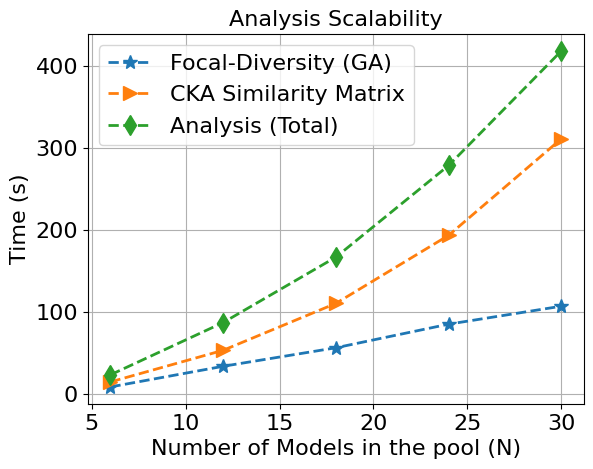

In [20]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({
        'font.size': 14,              # General font size
        'axes.titlesize': 16,         # Title font size
        'axes.labelsize': 16,         # Axis label font size
        'xtick.labelsize': 16,        # X-axis tick font size
        'ytick.labelsize': 16,        # Y-axis tick font size
        'legend.fontsize': 16         # Legend font size
        
    })


data = {
    "Focal-Diversity (GA)": np.array([8.67, 33.85, 56.45, 85.24, 107.17]),
    "CKA Similarity Matrix": np.array([14.77999434, 53.37284388, 110.600672, 193.6471305, 311.49])
}

data["Analysis (Total)"] = data["Focal-Diversity (GA)"] + data["CKA Similarity Matrix"]

x_axis = np.array([6, 12, 18, 24, 30])

fig, ax = plt.subplots()


markers = ["--*", "-->", "--d"]
for i, (k, v) in enumerate(data.items()):
    ax.plot(x_axis, v, markers[i], label=k, color=f"C{i}", markersize=10, lw=2, zorder=4)

ax.legend()
ax.grid(zorder=1)
ax.set_ylabel("Time (s)")
ax.set_xlabel("Number of Models in the pool (N)")
ax.set_title("Analysis Scalability")
plt.savefig("../results/figures/scalibility.png", dpi=200, bbox_inches="tight")
plt.show()


In [21]:
data

{'Focal-Diversity (GA)': array([  8.67,  33.85,  56.45,  85.24, 107.17]),
 'CKA Similarity Matrix': array([ 14.77999434,  53.37284388, 110.600672  , 193.6471305 ,
        311.49      ]),
 'Analysis (Total)': array([ 23.44999434,  87.22284388, 167.050672  , 278.8871305 ,
        418.66      ])}

In [ ]:
import time

times = []
for num_models in [6, 12, 18, 24, 30]:
    concat_data = [torch.randn(num_samples, num_dim) for i in range(num_models)]
    start = time.perf_counter()
    B = calc_cka_matrix(concat_data)
    end = time.perf_counter()
    elapsed = end-start
    times.append(elapsed)
    print(elapsed)

In [6]:
B

array([[1.        , 0.76459849, 0.76511554, 0.7650181 , 0.76445275,
        0.76533211],
       [0.76459849, 1.        , 0.76521139, 0.76456125, 0.76515671,
        0.76451265],
       [0.76511554, 0.76521139, 1.        , 0.76456915, 0.76496491,
        0.76492087],
       [0.7650181 , 0.76456125, 0.76456915, 1.        , 0.76484603,
        0.76478547],
       [0.76445275, 0.76515671, 0.76496491, 0.76484603, 1.        ,
        0.76537662],
       [0.76533211, 0.76451265, 0.76492087, 0.76478547, 0.76537662,
        1.        ]])

In [19]:
def calc_focal_cka(comb, S):
    avg_cka = 0
    count = 0
    for i, j in itertools.combinations(comb, 2):
        avg_cka += S[i, j]
        count += 1
    avg_cka = avg_cka / count
    return avg_cka


# Load Model predictions

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import pandas as pd
from data_generator.data_loader import DataCreator


for i in range(len(model_names)):
    data_name = f"results/inference/okvqa/validation/{model_names[i]}_output.csv"
    data_df = pd.read_csv(data_name, index_col=0)
    # print(data_df.head())


ds_creator = DataCreator("okvqa")
i = 0
skip_list = []
for dataset_obj in ds_creator.get("validation"):
    for example in dataset_obj:
        images = [example[f"image_{i}"] for i in range(1, 8) if example[f"image_{i}"] is not None]
        if len(images) != 1 or example.get("question_type", "multiple-choice") == "open":
            skip_list.append(i)
            print(i)
        i += 1
        
        

In [ ]:
import os

from data_generator.inference_loader import load_infer_prob_data
from ens_pruning.ens_methods import voting

dataset_name = "mmmu" # okvqa
data = load_infer_prob_data(model_names, dataset_name, "validation")
label = data[:, -1]

model_probs = np.split(data[:, :-1], len(model_names), axis=1)
model_preds = []
for i in range(len(model_names)):
    print(np.mean(model_probs[i].argmax(1) == label))
    model_preds.append(model_probs[i].argmax(1))

model_preds = np.array(model_preds)
voting_ens = voting(model_preds.T, "plurality")

classifications = (model_preds == label).sum(axis=0)

In [ ]:
data

array([[0.24510753, 0.05642696, 0.30504125, ..., 0.        , 0.        ,
        1.        ],
       [0.19550647, 0.22857024, 0.12427147, ..., 0.        , 0.        ,
        2.        ],
       [0.47584754, 0.18061136, 0.        , ..., 0.        , 0.        ,
        1.        ],
       ...,
       [0.3869364 , 0.31091213, 0.05487925, ..., 0.        , 0.        ,
        0.        ],
       [0.16477445, 0.23602851, 0.11503109, ..., 0.        , 0.        ,
        1.        ],
       [0.3509697 , 0.05135821, 0.21622616, ..., 0.        , 0.        ,
        4.        ]])

In [10]:
import os
import re
import itertools
import numpy as np
import pandas as pd


infer_dir = "results/inference"

task_name = "okvqa"
ds_split = "validation"


model_names = ["llava-v1.6-vicuna-7b-hf", "llava-v1.6-vicuna-13b-hf",
               "Qwen2.5-VL-7B-Instruct", "InternVL2-8B",
               "deepseek-vl2-tiny", "deepseek-vl2-small"]

# model_names = ["llava-v1.6-vicuna-7b-hf", "llava-v1.6-vicuna-13b-hf", "Qwen2.5-VL-7B-Instruct", "InternVL2-8B", "deepseek-vl2-tiny"]


def extract_letter(text):
    match = re.search(r"\((\w)\)", text)
    return match.group(1) if match else ""

error_list, pred_list = [], []
for mn in model_names:
    data_path = os.path.join(infer_dir, task_name, ds_split, f"{mn}_output.csv")
    data_df = pd.read_csv(data_path)

    arr_path = os.path.join(infer_dir, task_name, ds_split, f"{mn}_prob.npy")
    prob_arr = np.load(arr_path)

    start_chr = 'A'
    choices = []
    for i in range(prob_arr.shape[1]):
        choices.append(start_chr)
        start_chr = chr(ord(start_chr) + 1)

    prob_pred = []
    for i in np.argmax(prob_arr, axis=1):
        prob_pred.append(choices[i])
    prob_pred = np.array(prob_pred, dtype=str)

    generated_outputs = data_df["generated_outputs"].values

    extracted_outputs = []
    for output in generated_outputs:
        pred_txt = str(output)[:10].strip()
        if "\n" in pred_txt:
            pred_txt = pred_txt.split("\n")[1]
        if "(" in pred_txt or ")" in pred_txt:
            pred_txt = extract_letter(pred_txt)
        extracted_outputs.append(pred_txt[:1].upper())
    extracted_outputs = np.array(extracted_outputs)

    labels = data_df["answer"].values.astype(str) 
    if task_name == "mmmu_pro" and "llava" not in mn:
        extracted_outputs = np.delete(extracted_outputs, (1017), axis=0)
        prob_pred = np.delete(prob_pred, (1017), axis=0)
        labels = np.delete(labels, (1017), axis=0)
        prob_arr = np.delete(prob_arr, (1017), axis=0)

    errors = labels == extracted_outputs.astype(str)
    error_list.append(errors.astype(int))
    acc = np.mean(errors)
    
    print(prob_arr.shape)
    print(mn, acc, np.mean(labels.astype(str) == prob_pred))

    label_idx = []
    for i in range(len(labels)):
        label_idx.append(choices.index(labels[i]))
    pred_list.append(np.argmax(prob_arr, 1))


(1145, 4)
llava-v1.6-vicuna-7b-hf 0.8244541484716157 0.8262008733624454
(1145, 4)
llava-v1.6-vicuna-13b-hf 0.8349344978165939 0.834061135371179
(1145, 4)
Qwen2.5-VL-7B-Instruct 0.8829694323144105 0.8724890829694323
(1145, 4)
InternVL2-8B 0.8497816593886462 0.8532751091703057
(1145, 4)
deepseek-vl2-tiny 0.7755458515283843 0.8008733624454148
(1145, 4)
deepseek-vl2-small 0.7004366812227074 0.7668122270742358


In [11]:

from ens_pruning.ens_metrics import calc_div_acc

hist_data = {
    "error_arr": np.array(error_list).T,
    "pred_arr": np.array(pred_list).T,
    "label_arr": np.array(label_idx).astype(int)
}

calc_div_acc(np.ones((len(model_names),), dtype=int), hist_data, [1, 1, 1, 1, 1, 1, 1, 1])


[np.float64(0.3215844196268615),
 np.float64(0.885589519650655),
 np.float64(0.7359126266280753),
 np.float64(0.7984128368859593),
 np.float64(0.4050098997135078),
 np.float64(0.18946142649199418),
 np.float64(0.39984133620819073),
 np.float64(0.6986309947600322)]

In [12]:
np.ones((len(model_names),))

array([1., 1., 1., 1., 1., 1.])

In [13]:

num_models = len(model_names)
scores = []
comb_list = []
ens_sizes = np.arange(2, num_models + 1)
for j, ens_size in enumerate(ens_sizes):
    print(ens_size)
    combinations = list(itertools.combinations(range(num_models), ens_size))
    for comb in combinations:
        comb_idx = np.zeros(num_models, dtype=int)
        comb_idx[list(comb)] = 1
        scores.append(calc_div_acc(comb_idx, hist_data, [1, 1, 1, 1, 1, 1, 1, 1])) # returns focal_div, acc_score, fleiss_kappa
        comb_list.append(comb_idx)
scores = np.array(scores)


2
3
4
5
6


In [16]:
acc_arr = scores[:, 1]
for i in range(8):
    # if i == 1:
    #     continue
    max_comb_idx = np.argmax(scores[:, i])
    print(acc_arr[max_comb_idx], comb_list[max_comb_idx])
    

0.8008733624454148 [0 0 1 0 0 1]
0.8882096069868995 [1 0 1 1 0 0]
0.8279475982532751 [1 1 0 0 0 0]
0.8279475982532751 [1 1 0 0 0 0]
0.8279475982532751 [1 1 0 0 0 0]
0.7903930131004366 [1 0 0 0 0 1]
0.8279475982532751 [1 1 0 0 0 0]
0.7676855895196506 [0 0 0 0 1 1]


/tmp/ipykernel_1740217/2592424704.py:39: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


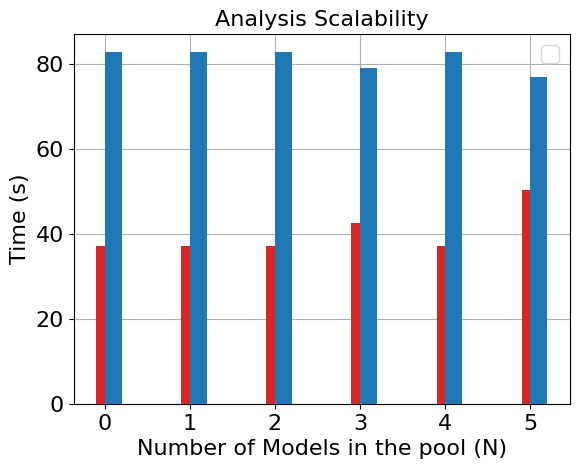

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
        'font.size': 14,              # General font size
        'axes.titlesize': 16,         # Title font size
        'axes.labelsize': 16,         # Axis label font size
        'xtick.labelsize': 16,        # X-axis tick font size
        'ytick.labelsize': 16,        # Y-axis tick font size
        'legend.fontsize': 16         # Legend font size
        
    })


data = {
    "Fleiss": [37.14, 82.79],
    "Q-statistics": [37.14, 82.79],
    "Corr. Co-Efficiency": [37.14, 82.79],
    "Binary Disag.": [42.61, 79.04],
    "Kappa": [37.14, 82.79],
    "Binary Entropy": [50.31, 76.77],
}

# data["Analysis (Total)"] = data["Focal-Diversity (GA)"] + data["CKA Similarity Matrix"]

x_axis = np.arange(len(data.keys()))

fig, ax = plt.subplots()

# "Focal-Diversity": [54.50, 88.31]/

ds_label = ["MMMU", "OKVQA"]
color = ["tab:red", "tab:blue"]
for i, (k, v) in enumerate(data.items()):
    for j in range(2):
        ax.bar(x_axis[i] + j*0.5, v[j], width=0.2, color=color[j], zorder=4)


ax.legend()
ax.grid(zorder=1)
ax.set_ylabel("Time (s)")
ax.set_xlabel("Number of Models in the pool (N)")
ax.set_title("Analysis Scalability")
plt.savefig("results/figures/metrics.png", dpi=200, bbox_inches="tight")
plt.show()


In [21]:
ens_sizes = np.arange(2, num_models + 1)
combs, cka_scores = [],[]
for j, ens_size in enumerate(ens_sizes):
    print(ens_size)
    combinations = list(itertools.combinations(range(num_models), ens_size))
    for comb in combinations:
        focal_cka_score = calc_focal_cka(comb, B)
        combs.append(comb)
        cka_scores.append(focal_cka_score)

2
3
4
5
6


/tmp/ipykernel_3005106/2866758356.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('jet', len(ens_sizes))


Text(0.5, 1.0, 'Accuracy vs Focal Div. of Ensembles (MMMU)')

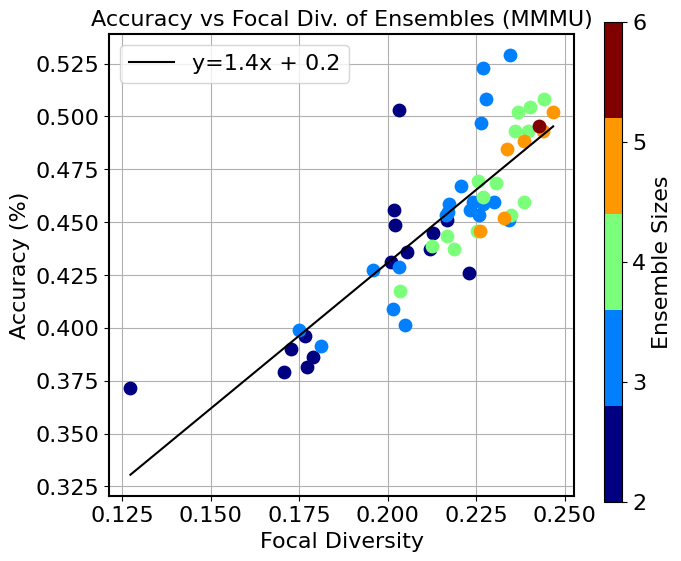

In [22]:
from matplotlib import cm
from matplotlib.cm import ScalarMappable
import matplotlib.colors as mcolors

plt.rcParams.update({
        'font.size': 14,              # General font size
        'axes.titlesize': 16,         # Title font size
        'axes.labelsize': 16,         # Axis label font size
        'xtick.labelsize': 16,        # X-axis tick font size
        'ytick.labelsize': 16,        # Y-axis tick font size
        'legend.fontsize': 16         # Legend font size
        
    })


fig, ax = plt.subplots(figsize=(6, 6))

normalize = mcolors.Normalize(vmin=2, vmax=ens_sizes[-1])
colormap = cm.get_cmap('jet', len(ens_sizes)) 
comb_sizes = np.array([len(j) for j in combs])
for i, ens_size in enumerate(ens_sizes):
    idx = comb_sizes == ens_size
    ax.scatter(scores[:, 0][idx], scores[:, 1][idx], s=80, color=np.array(colormap(normalize(ens_size))), zorder=2)

x, y = np.array(scores[:, 0]), np.array(scores[:, 1])
a, b = np.polyfit(x, y, 1)
x_axis = np.linspace(min(scores[:, 0]), max(scores[:, 0]), 100)
ax.plot(x_axis, x_axis * a + b, color="k", label=f"y={a:.1f}x + {b:.1f}", zorder=3)

scalarmappaple = cm.ScalarMappable(norm=normalize, cmap=colormap)
scalarmappaple.set_array(range(2, ens_sizes[-1]))
cax = fig.add_axes([0.95, 0.1, 0.03, 0.8])  # [left, bottom, width, height]
fig.colorbar(scalarmappaple, cax=cax, ticks=np.arange(2, ens_sizes[-1]+1), orientation='vertical', label='Ensemble Sizes', shrink=1, aspect=30)
ax.set_xlabel("Focal Diversity")
ax.set_ylabel("Accuracy (%)")
ax.grid(zorder=0)
# ax.set_xlim(0.3, 1)
ax.legend()
# cbar.ax.tick_params(labelsize=14)

ax.spines['top'].set_linewidth(1.5)
ax.spines['right'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)

ax.set_title("Accuracy vs Focal Div. of Ensembles (MMMU)")
# plt.savefig("focal_div_scatter.png", dpi=150, bbox_inches="tight")

In [26]:
acc_scores = scores[:, 1]
focal_div_scores = scores[:, 0]

In [27]:

for i in range(len(scores)):
    print(combs[i], acc_scores[i], cka_scores[i], focal_div_scores[i])

(0, 1) 0.37142857142857144 0.8971726719587675 0.12725126770414408
(0, 2) 0.45590062111801244 0.6356779332662813 0.20167140289839675
(0, 3) 0.44472049689440996 0.3760118552636751 0.21271898745216888
(0, 4) 0.39006211180124223 0.6637988480922445 0.17254243160384009
(0, 5) 0.38633540372670805 0.6758871375245747 0.17890313639284056
(1, 2) 0.43105590062111804 0.6431113590481911 0.20078514806574943
(1, 3) 0.4484472049689441 0.34492249586353907 0.20214042154089995
(1, 4) 0.39627329192546584 0.6208625848617352 0.17650531286894922
(1, 5) 0.37888198757763975 0.6376252385698831 0.17070158102766803
(2, 3) 0.5031055900621118 0.49278020548033435 0.20306092250454488
(2, 4) 0.4360248447204969 0.7504115259082187 0.20542390487761902
(2, 5) 0.4372670807453416 0.7887029627042053 0.21195364463146465
(3, 4) 0.4509316770186335 0.40955028850303643 0.21683242992042606
(3, 5) 0.4260869565217391 0.43757924223046923 0.22282790309106099
(4, 5) 0.3813664596273292 0.9529036248705319 0.17718326398284528
(0, 1, 2) 0.4

/tmp/ipykernel_3005106/2966759060.py:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('jet', len(ens_sizes))


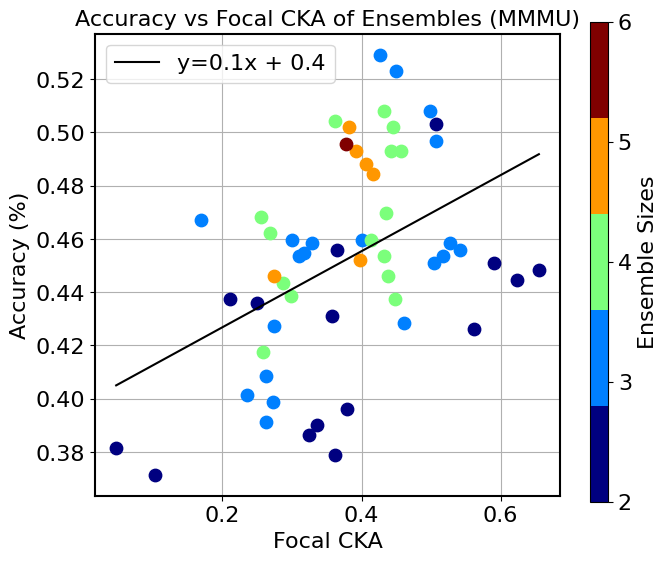

In [28]:

from matplotlib import cm
from matplotlib.cm import ScalarMappable
import matplotlib.colors as mcolors

plt.rcParams.update({
        'font.size': 14,              # General font size
        'axes.titlesize': 16,         # Title font size
        'axes.labelsize': 16,         # Axis label font size
        'xtick.labelsize': 16,        # X-axis tick font size
        'ytick.labelsize': 16,        # Y-axis tick font size
        'legend.fontsize': 16         # Legend font size
        
    })


fig, ax = plt.subplots(figsize=(6, 6))

cka_scores_neg = 1 - np.array(cka_scores)

normalize = mcolors.Normalize(vmin=2, vmax=ens_sizes[-1])
colormap = cm.get_cmap('jet', len(ens_sizes)) 
comb_sizes = np.array([len(j) for j in combs])
for i, ens_size in enumerate(ens_sizes):
    idx = comb_sizes == ens_size
    ax.scatter(np.array(cka_scores_neg)[idx], np.array(acc_scores)[idx], s=80, color=np.array(colormap(normalize(ens_size))), zorder=2)

x, y = np.array(cka_scores_neg), np.array(acc_scores)
a, b = np.polyfit(x, y, 1)
x_axis = np.linspace(min(cka_scores_neg), max(cka_scores_neg), 100)
ax.plot(x_axis, x_axis * a + b, color="k", label=f"y={a:.1f}x + {b:.1f}", zorder=3)

scalarmappaple = cm.ScalarMappable(norm=normalize, cmap=colormap)
scalarmappaple.set_array(range(2, ens_sizes[-1]))
cax = fig.add_axes([0.95, 0.1, 0.03, 0.8])  # [left, bottom, width, height]
fig.colorbar(scalarmappaple, cax=cax, ticks=np.arange(2, ens_sizes[-1]+1), orientation='vertical', label='Ensemble Sizes', shrink=1, aspect=30)
ax.set_xlabel("Focal CKA")
ax.set_ylabel("Accuracy (%)")
ax.grid(zorder=0)
# ax.set_xlim(0.3, 1)
ax.legend()
# cbar.ax.tick_params(labelsize=14)

ax.spines['top'].set_linewidth(1.5)
ax.spines['right'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)

ax.set_title("Accuracy vs Focal CKA of Ensembles (MMMU)")
plt.savefig("cka_scatter_neg.png", dpi=150, bbox_inches="tight")

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression().fit(np.array(cka_scores).reshape(1, -1), np.array(acc_scores).reshape(1, -1))
x_axis = np.linspace(min(cka_scores), max(cka_scores), 100)
y_pred = model.predict(np.array(cka_scores).reshape(1, -1))

In [29]:
cka_scores_neg = 1 - np.array(cka_scores)

In [30]:
acc_scores, cka_scores_neg, focal_div_scores

(array([0.37142857, 0.45590062, 0.4447205 , 0.39006211, 0.3863354 ,
        0.4310559 , 0.4484472 , 0.39627329, 0.37888199, 0.50310559,
        0.43602484, 0.43726708, 0.45093168, 0.42608696, 0.38136646,
        0.42732919, 0.42857143, 0.39875776, 0.39130435, 0.50807453,
        0.45465839, 0.45962733, 0.45341615, 0.45093168, 0.40124224,
        0.49689441, 0.45838509, 0.45341615, 0.45590062, 0.45838509,
        0.40869565, 0.52298137, 0.52919255, 0.46708075, 0.45962733,
        0.46956522, 0.43850932, 0.44347826, 0.43726708, 0.44596273,
        0.4173913 , 0.50186335, 0.50807453, 0.46832298, 0.45962733,
        0.4931677 , 0.4931677 , 0.4621118 , 0.45341615, 0.50434783,
        0.48447205, 0.48819876, 0.44596273, 0.45217391, 0.50186335,
        0.4931677 , 0.49565217]),
 array([0.10282733, 0.36432207, 0.62398814, 0.33620115, 0.32411286,
        0.35688864, 0.6550775 , 0.37913742, 0.36237476, 0.50721979,
        0.24958847, 0.21129704, 0.59044971, 0.56242076, 0.04709638,
        0.2746

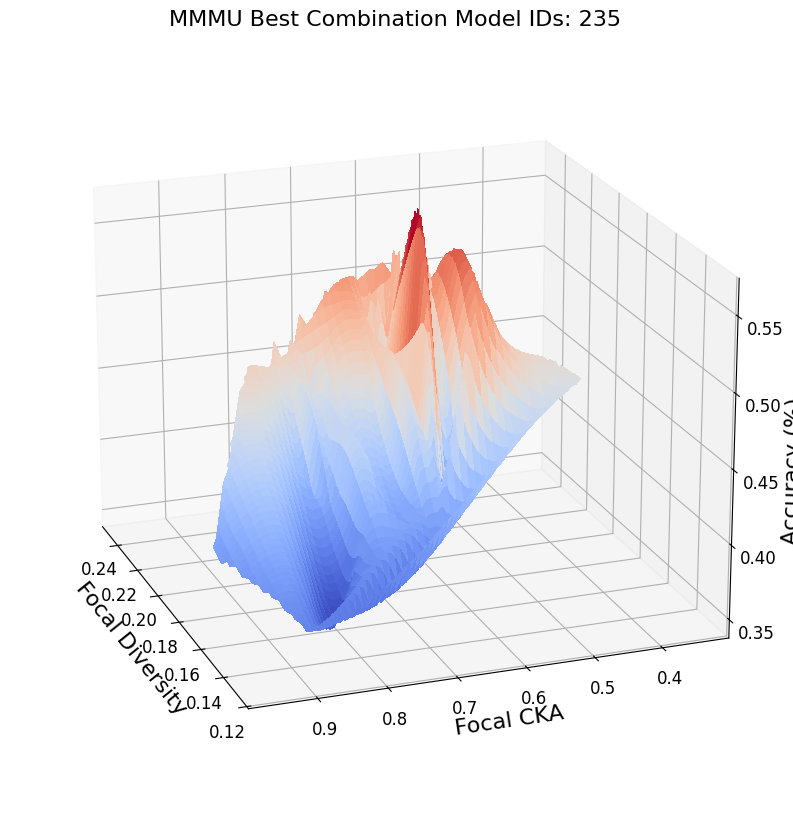

In [65]:
from scipy.interpolate import griddata
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.ticker import LinearLocator

plt.style.use('default')

# Set global font size for all elements
plt.rcParams.update({
    'font.size': 14,              # General font size
    'axes.titlesize': 16,         # Title font size
    'axes.labelsize': 16,         # Axis label font size
    'xtick.labelsize': 12,        # X-axis tick font size
    'ytick.labelsize': 12,        # Y-axis tick font size
    'legend.fontsize': 12         # Legend font size
})

X = np.array(focal_div_scores)
Y = np.array(cka_scores)
Z = np.array(acc_scores)
xi = np.linspace(X.min(),X.max(),100)
yi = np.linspace(Y.min(),Y.max(),100)
zi = griddata((X, Y), Z, (xi[None,:], yi[:,None]), method='cubic')

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(projection="3d")
xig, yig = np.meshgrid(xi, yi)
surf = ax.plot_surface(xig, yig, zi, cmap=cm.coolwarm,
                linewidth=1, antialiased=False, zorder=1)
ax.set_xlabel(r"Focal Diversity")
ax.set_ylabel(r"Focal CKA")
ax.set_zlabel("Accuracy (%)")

# Customize the z axis.
# ax.set_zlim(0.30, Z.max() + 0.05)
# ax.zaxis.set_major_locator(LinearLocator(10))
# # A StrMethodFormatter is used automatically
# ax.zaxis.set_major_formatter('{x:.02f}')
idx = np.argmax(scores[:, :2].mean(1))
best_model_ids = "".join([str(j) for j in np.argwhere(comb_list[idx]).squeeze()])

ax.view_init(elev=20., azim=-200)
ax.set_title(f"{task_name.upper()} Best Combination Model IDs: {best_model_ids}")
plt.savefig(f"results/figures/{task_name}_cka_focal.png", bbox_inches="tight", dpi=200)